# Proyek AI Engineer: Hirings Career Recommendation System
**Nama Tim:** AI Engineer Cohort – Hirings
**Anggota:**
- Ainur Roshidatul Ulla
- Alya Cahyani Humaira

**Tujuan:**
Mengembangkan sistem Artificial Intelligence berbasis Deep Learning dan Natural Language Processing (NLP) pada platform Hirings untuk mendukung fitur:
- Career Recommendation System
- Smart Job Matching
- Skill-Based Job Prediction
- AI Career Suggestion

In [ ]:
# =====================================================
# IMPORT LIBRARY
# =====================================================
!pip install sentence-transformers
# Basic Library
import os
import re
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# TensorFlow
import tensorflow as tf

# TensorFlow Layers
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LSTM
)

# TensorFlow Model
from tensorflow.keras.models import Model

# TensorFlow Callback
from tensorflow.keras.callbacks import (
    EarlyStopping,
    TensorBoard
)

# TensorFlow Optimizer & Loss
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError

# Sklearn
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

# Scipy
from scipy.sparse import load_npz

# NLP
from sentence_transformers import (
    SentenceTransformer
)

# Visualization
plt.style.use('ggplot')

In [ ]:
# =====================================================
# LOAD DATASET
# =====================================================

df = pd.read_csv(
    'linkedin_jobs_cleaned (1).csv',
    engine='python',
    on_bad_lines='skip'
)

print(df.head())
print(df.shape)

     job_id  company_id                                              title  \
0    921716   2774458.0                              Marketing Coordinator   
1   1829192         NaN                  Mental Health Therapist/Counselor   
2  10998357  64896719.0                        Assitant Restaurant Manager   
3  23221523    766262.0  Senior Elder Law / Trusts and Estates Associat...   
4  35982263         NaN                                 Service Technician   

                                         description  \
0  Job descriptionA leading real estate firm in N...   
1  At Aspen Therapy and Wellness , we are committ...   
2  The National Exemplar is accepting application...   
3  Senior Associate Attorney - Elder Law / Trusts...   
4  Looking for HVAC service tech with experience ...   

                                   clean_description  max_salary  min_salary  \
0  job descriptiona leading real estate firm new ...        20.0        17.0   
1  aspen therapy wellness committe

In [ ]:
# =====================================================
# LOAD JOB EMBEDDINGS
# =====================================================

job_embeddings = np.load(
    'job_embeddings (1).npy'
)

print(job_embeddings.shape)

(123824, 384)


In [ ]:
# =====================================================
# ALIGN DATASET WITH EMBEDDINGS
# =====================================================

print('Original Dataset Shape:', df.shape)
print('Embedding Shape:', job_embeddings.shape)

# Samakan jumlah row
min_rows = min(
    len(df),
    len(job_embeddings)
)

df = df.iloc[:min_rows]

job_embeddings = job_embeddings[:min_rows]

print('Aligned Dataset Shape:', df.shape)
print('Aligned Embedding Shape:', job_embeddings.shape)

Original Dataset Shape: (123824, 13)
Embedding Shape: (123824, 384)
Aligned Dataset Shape: (123824, 13)
Aligned Embedding Shape: (123824, 384)


In [ ]:
# =====================================================
# DATA UNDERSTANDING
# =====================================================

print(df.columns)

print(df.info())

Index(['job_id', 'company_id', 'title', 'description', 'clean_description',
       'max_salary', 'min_salary', 'location', 'formatted_experience_level',
       'applies', 'views', 'remote_allowed', 'job_posting_url'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123824 entries, 0 to 123823
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123824 non-null  int64  
 1   company_id                  122115 non-null  float64
 2   title                       123824 non-null  object 
 3   description                 123824 non-null  object 
 4   clean_description           123824 non-null  object 
 5   max_salary                  123824 non-null  float64
 6   min_salary                  123824 non-null  float64
 7   location                    123824 non-null  object 
 8   formatted_experience_level  94437 non-null   object 
 9   applie

In [ ]:
# =====================================================
# COMBINE TEXT FEATURE
# =====================================================

df['combined_text'] = (
    df['title'].astype(str) + ' ' +
    df['description'].astype(str)
)

print(df['combined_text'].head())

0    Marketing Coordinator Job descriptionA leading...
1    Mental Health Therapist/Counselor At Aspen The...
2    Assitant Restaurant Manager The National Exemp...
3    Senior Elder Law / Trusts and Estates Associat...
4    Service Technician Looking for HVAC service te...
Name: combined_text, dtype: object


In [ ]:
# =====================================================
# TF-IDF FEATURE EXTRACTION
# =====================================================

# LOAD TF-IDF MATRIX
tfidf_matrix = load_npz(
    'tfidf_matrix.npz'
)

#LOAD TF-IDF VECTORIZER
tfidf_vectorizer = joblib.load(
    'tfidf_vectorizer.pkl'
)

print('TF-IDF assets loaded!')
print(tfidf_matrix.shape)

TF-IDF assets loaded!
(123824, 5000)


In [ ]:
# =====================================================
# LOAD SENTENCE TRANSFORMER
# =====================================================

embedding_model = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

print('Embedding model loaded!')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded!


In [ ]:
# =====================================================
# HYBRID RECOMMENDATION FUNCTION
# =====================================================

def recommend_jobs(
    user_input,
    top_k=5
):

    # =====================================
    # EMBEDDING SIMILARITY
    # =====================================

    user_embedding = embedding_model.encode(
        [user_input]
    )

    embedding_similarity = cosine_similarity(
        user_embedding,
        job_embeddings
    )[0]

    # =====================================
    # TF-IDF SIMILARITY
    # =====================================

    user_tfidf = tfidf_vectorizer.transform(
        [user_input]
    )

    tfidf_similarity = cosine_similarity(
        user_tfidf,
        tfidf_matrix
    )[0]

    # =====================================
    # HYBRID SCORE
    # =====================================

    final_similarity = (
        0.5 * embedding_similarity
        +
        0.5 * tfidf_similarity
    )

    # =====================================
    # TOP RESULT
    # =====================================

    top_indices = np.argsort(
        final_similarity
    )[-top_k:][::-1]

    # =====================================
    # RECOMMENDATION RESULT
    # =====================================

    recommendations = df.iloc[
        top_indices
    ][[
        'job_id',
        'company_id',
        'title',
        'location'
    ]]

    return recommendations

In [ ]:
# =====================================================
# TEST RECOMMENDATION
# =====================================================

user_skill = (
    'Python SQL TensorFlow '
    'Machine Learning Data Analysis'
)

recommendation_result = recommend_jobs(
    user_skill
)

print(recommendation_result)

            job_id  company_id  \
33606   3895215696  13331595.0   
69654   3902828481   3715179.0   
20947   3889411404      7952.0   
50597   3901374682  35719183.0   
101383  3905248248  35719183.0   

                                                    title       location  
33606                                        Data Analyst  United States  
69654   Remote opportunity for P&C Insurance Data Scie...  United States  
20947   Certified Medical Assistant – Family Care - Fu...  Sunnyvale, TX  
50597    Data Quality Engineer - Spark/PySpark/Databricks  United States  
101383  Data Quality Engineer - Spark/PySpark/Databric...  United States  


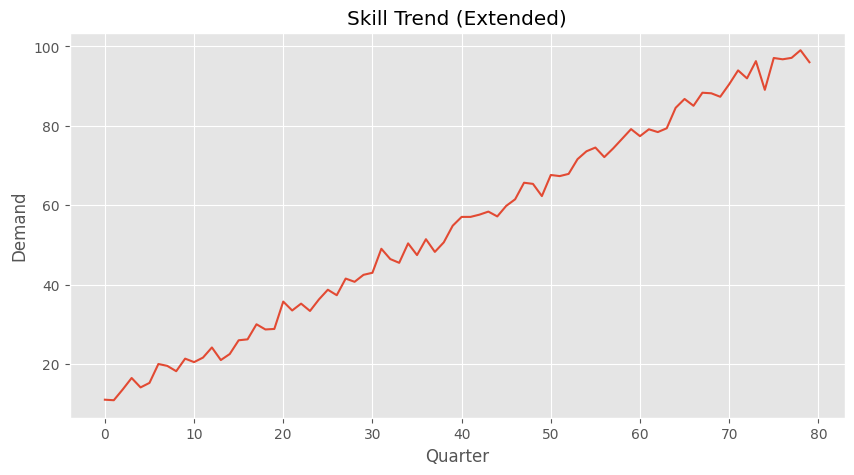

In [ ]:
# =====================================================
# CREATE FORECASTING DATA
# =====================================================

# Data deret waktu diperluas agar LSTM dapat belajar pola secara optimal
np.random.seed(42)
base_trend = np.linspace(10, 100, 80)
noise = np.random.normal(0, 2, 80)
skill_trend = (base_trend + noise).astype(float)

plt.figure(figsize=(10,5))
plt.plot(skill_trend)
plt.title('Skill Trend (Extended)')
plt.xlabel('Quarter')
plt.ylabel('Demand')
plt.show()

In [ ]:
# =====================================================
# NORMALIZATION
# =====================================================

scaler = MinMaxScaler()

skill_scaled = scaler.fit_transform(
    skill_trend.reshape(-1,1)
)

In [ ]:
# =====================================================
# CREATE SEQUENCE
# =====================================================

X = []
y = []

window_size = 3

for i in range(
    len(skill_scaled) - window_size
):

    X.append(
        skill_scaled[i:i+window_size]
    )

    y.append(
        skill_scaled[i+window_size]
    )

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(9, 3, 1)
(9, 1)


In [ ]:
# =====================================================
# CUSTOM CALLBACK
# =====================================================

class CustomCallback(
    tf.keras.callbacks.Callback
):

    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):

        loss = logs.get('loss')

        print(
            f'Epoch {epoch+1} Loss: {loss}'
        )

In [ ]:
# =====================================================
# BUILD LSTM MODEL
# =====================================================

inputs = Input(
    shape=(window_size,1)
)

x = LSTM(
    64,
    activation='tanh'
)(inputs)

x = Dense(
    32,
    activation='relu'
)(x)

outputs = Dense(1)(x)

forecast_model = Model(
    inputs=inputs,
    outputs=outputs
)

forecast_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 3, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =====================================================
# COMPILE MODEL
# =====================================================

# Learning rate diperkecil agar gradient descent lebih stabil
forecast_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=MeanSquaredError(),
    metrics=['mae']
)

In [ ]:
# =====================================================
# TENSORBOARD
# =====================================================

tensorboard_callback = TensorBoard(
    log_dir='logs'
)

In [ ]:
# =====================================================
# EARLY STOPPING
# =====================================================

early_stopping = EarlyStopping(
    monitor='loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
# =====================================================
# TRAIN MODEL
# =====================================================

# Epoch diperbanyak agar model punya cukup waktu untuk konvergen
history = forecast_model.fit(
    X,
    y,
    epochs=300,
    callbacks=[
        CustomCallback(),
        tensorboard_callback,
    ]
)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.3717 - mae: 0.5511Epoch 1 Loss: 0.3717428147792816
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.3717 - mae: 0.5511
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.3522 - mae: 0.5352Epoch 2 Loss: 0.352167546749115
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.3522 - mae: 0.5352
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.3326 - mae: 0.5192Epoch 3 Loss: 0.33264875411987305
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.3326 - mae: 0.5192
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.3135 - mae: 0.5031Epoch 4 Loss: 0.3134737014770508
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - loss: 0.3135 - mae: 0.5031
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - loss: 0.2946 - mae: 0.4868Epoch 5 Loss: 0.29461997747421265
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - loss: 0.2946 - mae: 0.4868
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.2763 - mae: 0.4705Epoch 6 Loss: 0.276252895

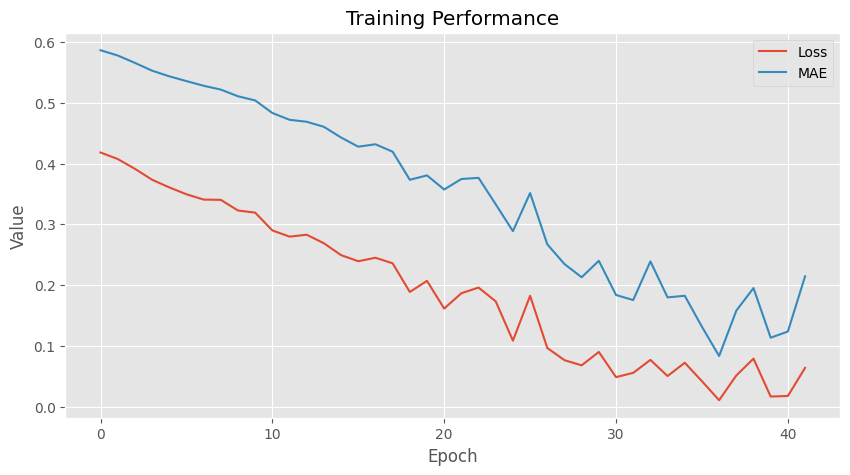

In [ ]:
# =====================================================
# TRAINING VISUALIZATION
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])

plt.plot(history.history['mae'])

plt.title('Training Performance')

plt.xlabel('Epoch')

plt.ylabel('Value')

plt.legend([
    'Loss',
    'MAE'
])

plt.show()

In [ ]:
# =====================================================
# CUSTOM TRAINING LOOP
# =====================================================

optimizer = Adam()

loss_fn = MeanSquaredError()

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X, y)
).batch(2)

for epoch in range(3):

    print(f'Epoch {epoch+1}')

    for step, (
        x_batch,
        y_batch
    ) in enumerate(train_dataset):

        with tf.GradientTape() as tape:

            predictions = forecast_model(
                x_batch,
                training=True
            )

            loss_value = loss_fn(
                y_batch,
                predictions
            )

        grads = tape.gradient(
            loss_value,
            forecast_model.trainable_weights
        )

        optimizer.apply_gradients(
            zip(
                grads,
                forecast_model.trainable_weights
            )
        )

    print(
        'Loss:',
        float(loss_value)
    )

Epoch 1
Loss: 0.3076136112213135
Epoch 2
Loss: 0.035587411373853683
Epoch 3
Loss: 0.0006601424538530409


In [ ]:
# =====================================================
# SAVE MODEL
# =====================================================

forecast_model.save(
    'skill_forecast_model.keras'
)

print('Model saved!')

Model saved!


In [ ]:
# =====================================================
# LOAD MODEL
# =====================================================

loaded_model = tf.keras.models.load_model(
    'skill_forecast_model.keras'
)

In [ ]:
# =====================================================
# FORECAST FUNCTION
# =====================================================

def predict_skill_trend(
    input_sequence
):

    input_scaled = scaler.transform(
        np.array(input_sequence)
        .reshape(-1,1)
    )

    input_scaled = input_scaled.reshape(
        1,
        window_size,
        1
    )

    prediction = loaded_model.predict(
        input_scaled
    )

    prediction = scaler.inverse_transform(
        prediction
    )

    return prediction[0][0]

In [ ]:
# =====================================================
# TEST FORECASTING
# =====================================================

sample_data = [70, 80, 90]

forecast_result = predict_skill_trend(
    sample_data
)

print(
    'Predicted Next Trend:',
    forecast_result
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
Predicted Next Trend: 88.69312


In [ ]:
# =====================================================
# AI CAREER SUGGESTION GENERATOR
# =====================================================

def generate_career_suggestion(skills):

    skills_lower = skills.lower()

    suggestion = ""

    # ==========================================
    # AI / DATA
    # ==========================================

    if (
        'python' in skills_lower
        or 'machine learning' in skills_lower
        or 'tensorflow' in skills_lower
    ):

        suggestion = f"""

        Based on your current skills in {skills},
        you are highly suitable for AI and Data-related careers
        such as Data Scientist, Machine Learning Engineer,
        or AI Engineer.

        To improve your career opportunities,
        consider learning:
        - Deep Learning
        - MLOps
        - Cloud Computing
        - NLP

        Your profile indicates strong potential
        in the AI industry.

        """

    # ==========================================
    # WEB DEVELOPMENT
    # ==========================================

    elif (
        'javascript' in skills_lower
        or 'react' in skills_lower
        or 'flutter' in skills_lower
    ):

        suggestion = f"""

        Based on your current skills in {skills},
        you are suitable for software development roles
        such as Frontend Developer, Mobile Developer,
        or Fullstack Developer.

        To advance your career,
        consider improving:
        - Backend Development
        - API Integration
        - System Design
        - Cloud Deployment

        Your profile shows strong potential
        in modern software engineering careers.

        """

    # ==========================================
    # DEFAULT
    # ==========================================

    else:

        suggestion = f"""

        Based on your skills in {skills},
        you have potential in several technology-related careers.

        Continue improving both technical and communication skills
        to increase your competitiveness in the job market.

        """

    return suggestion

In [ ]:
# =====================================================
# TEST AI CAREER SUGGESTION
# =====================================================

result = generate_career_suggestion(
    "Python SQL Machine Learning"
)

print(result)



        Based on your current skills in Python SQL Machine Learning,
        you are highly suitable for AI and Data-related careers
        such as Data Scientist, Machine Learning Engineer,
        or AI Engineer.

        To improve your career opportunities,
        consider learning:
        - Deep Learning
        - MLOps
        - Cloud Computing
        - NLP

        Your profile indicates strong potential
        in the AI industry.

        


In [ ]:
# =====================================================
# INSTALL FASTAPI
# =====================================================

!pip install fastapi uvicorn pyngrok nest-asyncio

In [ ]:
# =====================================================
# SAVE TF-IDF VECTORIZER
# =====================================================

joblib.dump(
    tfidf_vectorizer,
    'tfidf_vectorizer.pkl'
)

print('TF-IDF saved!')

TF-IDF saved!


In [ ]:
# =====================================================
# SAVE DATASET
# =====================================================

df.to_csv(
    'final_jobs_data.csv',
    index=False
)

print('Dataset saved!')

Dataset saved!


In [ ]:
# =====================================================
# CREATE FASTAPI APP
# =====================================================

from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI()

print('FastAPI initialized!')

FastAPI initialized!


In [ ]:
# =====================================================
# ROOT ENDPOINT
# =====================================================

@app.get("/")

def home():

    return {
        "message": "Hirings AI API is running!"
    }

In [ ]:
# =====================================================
# REQUEST SCHEMA
# =====================================================

class RecommendationRequest(BaseModel):
    skills: str

class ForecastRequest(BaseModel):
    trend: list

class CareerSuggestionRequest(BaseModel):
    skills: str

In [ ]:
# =====================================================
# RECOMMENDATION API
# =====================================================

@app.post("/recommend")

def recommend_api(data: RecommendationRequest):

    result = recommend_jobs(
        data.skills
    )

    return result.to_dict(
        orient='records'
    )

In [ ]:
# =====================================================
# FORECAST API
# =====================================================

@app.post("/forecast")

def forecast_api(data: ForecastRequest):

    prediction = predict_skill_trend(
        data.trend
    )

    return {
        'prediction': float(prediction)
    }

In [ ]:
# =====================================================
# AI CAREER SUGGESTION API
# =====================================================

@app.post("/career-suggestion")

def career_suggestion_api(
    data: CareerSuggestionRequest
):

    result = generate_career_suggestion(
        data.skills
    )

    return {
        'career_suggestion': result
    }

In [ ]:
# =====================================================
# CREATE REQUIREMENTS.TXT
# =====================================================

requirements = """

tensorflow
pandas
numpy
scikit-learn
sentence-transformers
fastapi
uvicorn
joblib

"""

with open(
    'requirements.txt',
    'w'
) as f:

    f.write(requirements)

print('requirements.txt created!')

requirements.txt created!


In [ ]:
# =====================================================
# DOWNLOAD FILES
# =====================================================

from google.colab import files

files.download(
    'skill_forecast_model.keras'
)

files.download(
    'tfidf_vectorizer.pkl'
)

files.download(
    'requirements.txt'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =====================================================
# RUN API
# =====================================================

from pyngrok import ngrok
import nest_asyncio
import uvicorn

# ==========================================
# NGROK AUTH TOKEN
# ==========================================

ngrok.set_auth_token(
    "3DeqxuGwGZ1JgyesnYUOolKeX8C_869jRBmNr8YASfLkKauf3"
)

# ==========================================
# FIX COLAB ASYNC ISSUE
# ==========================================

nest_asyncio.apply()

# ==========================================
# CREATE PUBLIC URL
# ==========================================

public_url = ngrok.connect(8000)

print('Public URL:', public_url)

# ==========================================
# RUN FASTAPI
# ==========================================

config = uvicorn.Config(
    app,
    host='0.0.0.0',
    port=8000
)

server = uvicorn.Server(config)

await server.serve()

Public URL: NgrokTunnel: "https://disband-schedule-waffle.ngrok-free.dev" -> "http://localhost:8000"


INFO:     Started server process [2941]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     139.0.95.52:0 - "GET / HTTP/1.1" 404 Not Found
INFO:     139.0.95.52:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [2941]
